## Algorithmic Back-testing Summer Project: ##

#### Can a systematic rule-based strategy applied to SPY's historical price data generate better risk-adjusted returns than simply buying and holding SPY? ####

In [1]:
import sys
sys.path.append('..')

from src.data_pipeline import load_data
import matplotlib.pyplot as plt

# Load SPY data
df = load_data('SPY', '2010-01-01', '2024-01-01')

# Basic inspection
print(df.shape)
print(df.head())
print(df.describe())

Matplotlib is building the font cache; this may take a moment.


[*********************100%***********************]  1 of 1 completed

Downloaded 3522 rows of data
(3521, 6)
Price           Close       High        Low       Open     Volume log_returns
Ticker            SPY        SPY        SPY        SPY        SPY            
Date                                                                         
2010-01-05  84.802383  84.839701  84.220268  84.526255  111579900    0.002644
2010-01-06  84.862068  85.071032  84.653104  84.720269  116074400    0.000704
2010-01-07  85.220299  85.324781  84.466532  84.705348  131091100    0.004212
2010-01-08  85.503883  85.541201  84.824751  84.996397  126402800    0.003322
2010-01-11  85.623322  85.921838  85.257629  85.884526  106375700    0.001396
Price         Close         High          Low         Open        Volume  \
Ticker          SPY          SPY          SPY          SPY           SPY   
count   3521.000000  3521.000000  3521.000000  3521.000000  3.521000e+03   
mean     224.239661   225.441577   222.855647   224.197962  1.156964e+08   
std      109.792779   110.450656 

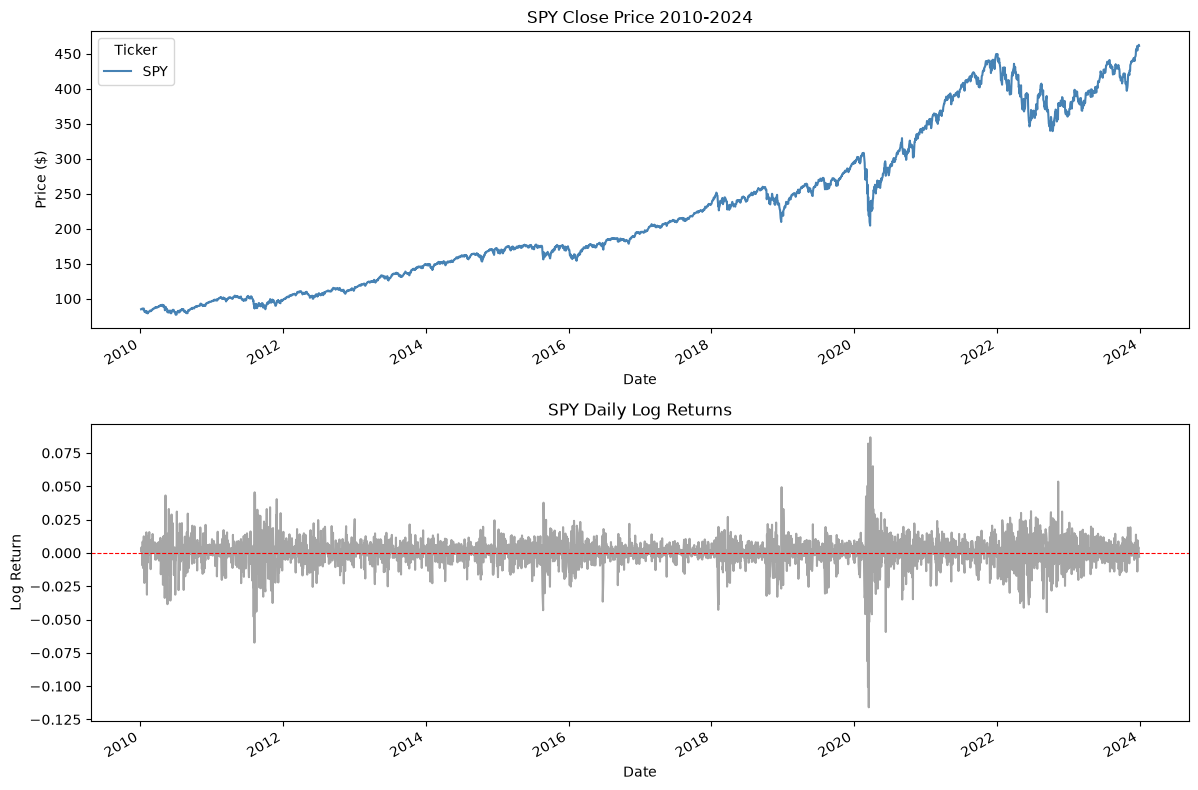

In [2]:
# Plot the price series
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

df['Close'].plot(ax=ax1, title='SPY Close Price 2010-2024', color='steelblue')
ax1.set_ylabel('Price ($)')

df['log_returns'].plot(ax=ax2, title='SPY Daily Log Returns', color='grey', alpha=0.7)
ax2.set_ylabel('Log Return')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

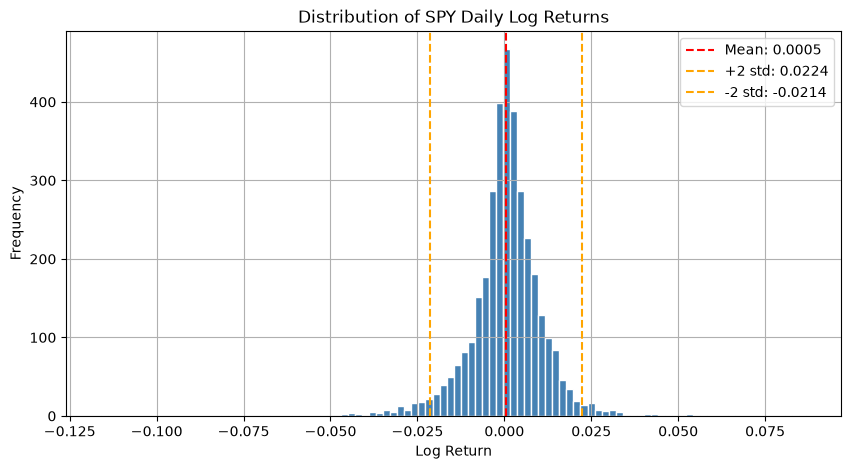

Mean daily return: 0.0005
Daily volatility: 0.0109
Annualised volatility: 0.1738
Skewness: -0.7178
Kurtosis: 11.5114


In [3]:
# Distribution of returns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
df['log_returns'].hist(bins=100, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of SPY Daily Log Returns')
ax.set_xlabel('Log Return')
ax.set_ylabel('Frequency')

# Add mean and std lines
mean = df['log_returns'].mean()
std = df['log_returns'].std()
ax.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.4f}')
ax.axvline(mean + 2*std, color='orange', linestyle='--', label=f'+2 std: {mean+2*std:.4f}')
ax.axvline(mean - 2*std, color='orange', linestyle='--', label=f'-2 std: {mean-2*std:.4f}')
ax.legend()
plt.show()

print(f"Mean daily return: {mean:.4f}")
print(f"Daily volatility: {std:.4f}")
print(f"Annualised volatility: {std * np.sqrt(252):.4f}")
print(f"Skewness: {df['log_returns'].skew():.4f}")
print(f"Kurtosis: {df['log_returns'].kurtosis():.4f}")